In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt

from leakage.conversions import dB
from sca_module.readers import create_dataset
from sca_module.dopsca_setup import DopSCAConfig
from sca_module.simulate_L1 import compute_beam_pattern, compute_cube_observation_geometry, compute_true_observations, create_observation_cube, compute_lpf_cube, add_L1_uncertainties

func_rmse = lambda x, rounding=3:  np.round(np.sqrt(np.nanmean(x**2)), rounding)

plt.rcParams.update({'font.size': 10, 'font.weight' : 'bold'})

## 0 - Parameters

In [2]:
sca = DopSCAConfig()
sca.Lambda = sca.get_wavelength()
sca.grid_spacing_target = sca.get_grid_spacing_target(magic_divider=2)

## 1 - Load data

In [ ]:
files_cali = [
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_input_California.nc',
    '/Users/opodriscoll/Documents/projects/DopSCA MOMS/ATBD/data/SWB_output_California.nc'
]

simulation = xr.open_mfdataset(files_cali, compat='no_conflicts', engine='netcdf4').sel(sat = 'S1').compute()
sca.magic_offset = sca.get_magic_offset(incidence_min=simulation.inc.min().data)

# clipping unreasonable incidence angles
simulation = simulation.sel(grg = slice(sca.grg_min - sca.magic_offset, sca.grg_max - sca.magic_offset))

In [4]:
# Here we interpolate to finer grid spacing, 
new_az = np.arange(simulation.az.min(), simulation.az.max(), sca.grid_spacing_target)
new_grg = np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_target)
simulation = simulation.interp(az=new_az, grg=new_grg)

## 2 - Add necessary fields

In [5]:
nrcs = simulation[sca.var_nrcs].sel(pol='M')
dop = simulation[sca.var_dop].sel(pol='M')
inc_2d = np.degrees(simulation[sca.var_inc].expand_dims(dim={sca.dim_az: simulation.az.data}))

data = create_dataset(
    nrcs=nrcs.data,
    dop=dop.data,
    inc=inc_2d.data,
    grg=simulation.grg.data + sca.magic_offset,
    az=simulation.az.data,
    grid_spacing=sca.grid_spacing_target,
)

## 3 - Convert to 3D observation cube

In [6]:
data_cube = create_observation_cube(data, sca.az_footprint_cutoff, sca.grid_spacing_target, sca.vx_sat, sca.PRF).compute()
data_cube = compute_cube_observation_geometry(data_cube, sca.dim_az_beam, sca.dim_az_slow_time, sca.dim_range, sca.var_inc, sca.z0, sca.boresight_elevation_angle_scat)

data_cube = data_cube.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

## 4 - Add hypothetical beam pattern

In [7]:
beam = compute_beam_pattern(
    az_angle_wrt_boresight=data_cube.az_angle_wrt_boresight,
    grg_angle_wrt_boresight=data_cube.grg_angle_wrt_boresight,
    antenna_elements=sca.antenna_elements,
    antenna_weighting=sca.antenna_weighting,
    antenna_length=sca.antenna_length,
    antenna_height=sca.antenna_height,
    f0=sca.f0,
    beam_pattern=sca.beam_pattern,
)

data_cube['beam'] = ([sca.dim_az_beam, sca.dim_range], beam)

## 5 - Estimate idealized scaterometer observations

In [8]:
data_cube = compute_true_observations(data_cube, sca.var_nrcs, sca.var_inc, sca.dim_az_beam, sca.vx_sat, sca.Lambda, var_azimuth_angle_wrt_boresight = "az_angle_wrt_boresight")
data_cube = data_cube.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

## 6 - Add uncertainties with SCR computed from the NRCS field

In [9]:
ds = add_L1_uncertainties(
    ds = data_cube,
    dim_range = sca.dim_range,
    dim_az_beam = sca.dim_az_beam,
    vx_sat = sca.vx_sat,
    U = sca.U,
    sat_height = sca.z0,
    T_pp= sca.T_pp,
    Lambda = sca.Lambda,
    fixed_SCR=None, # < -------- here we let the SCR be calculated from the NRCS data 
    grid_spacing_slant_range=sca.grid_spacing_slant_range_SCA,
    random_state=sca.random_state
)

# -- Resample to uniform ground-range spacing
ds = ds.interp(
        grg=np.arange(
            simulation.grg.min(), 
            simulation.grg.max(), 
            sca.grid_spacing_slant_range_SCA
        ) + sca.magic_offset, 
        method=sca.interpolator
    ).astype("float32")
ds = ds.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

## 7 - Low-pass filter to product resolution and drop domain with insufficient data 

In [10]:
fs_y, fs_x = 1 / sca.grid_spacing_slant_range_SCA, 1 / ds.attrs["stride"]

data_2_lpf : list[str] = [
            "V_pp",
            "V_sigma",
            "V_leakage_pulse_rg"
        ]

ds = compute_lpf_cube(ds, fs_y, fs_x, sca.resolution_product, data_2_lpf, crop_edges = True)

ds = ds.dropna(subset = ['nrcs_scat_speckle'], dim = sca.dim_range, how='any')

In [11]:
func_rmse(ds.V_leakage_pulse_rg_lpf), func_rmse(ds.V_leakage_pulse_rg), func_rmse(ds.V_pp), func_rmse(ds.V_pp_lpf), func_rmse(ds.V_sigma), func_rmse(ds.V_sigma_lpf)

(1.379, 1.803, 75.176, 1.868, 75.204, 2.464)

## 8 - Correct for the incurred leakage residual

### 8.1 - Remove the NaN edges, which can mess up successive computations

In [18]:
data['nrcs_scat_speckle'] = ([*data['nrcs'].dims], ds['nrcs_scat_speckle'].interp({"az_slow_time":data.az.data, "grg":data.grg.data}).data)
mask = data["nrcs_scat_speckle"].notnull()
data_clean = data.where(mask, drop=True)

### 8.2 - Repeat the leakage estimation, but now using a realization of SCA's estimated NRCS

In [20]:
data_cube_ = create_observation_cube(data_clean, sca.az_footprint_cutoff, sca.grid_spacing_target, sca.vx_sat, sca.PRF, dropna=False).compute()
data_cube_ = compute_cube_observation_geometry(data_cube_, sca.dim_az_beam, sca.dim_az_slow_time, sca.dim_range, sca.var_inc, sca.z0, sca.boresight_elevation_angle_scat)

data_cube_ = data_cube_.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

beam = compute_beam_pattern(
    az_angle_wrt_boresight=data_cube_.az_angle_wrt_boresight,
    grg_angle_wrt_boresight=data_cube_.grg_angle_wrt_boresight,
    antenna_elements=sca.antenna_elements,
    antenna_weighting=sca.antenna_weighting,
    antenna_length=sca.antenna_length,
    antenna_height=sca.antenna_height,
    f0=sca.f0,
    beam_pattern=sca.beam_pattern,
)

data_cube_['beam'] = ([sca.dim_az_beam, sca.dim_range], beam)

# here we use 'nrcs_scat_speckle' as the input NRCS, rather than the noise-free version
data_cube_ = compute_true_observations(data_cube_, 'nrcs_scat_speckle', sca.var_inc, sca.dim_az_beam, sca.vx_sat, sca.Lambda, var_azimuth_angle_wrt_boresight = "az_angle_wrt_boresight")
data_cube_ = data_cube_.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

ds_ = data_cube_

ds_ = ds_.interp(grg=np.arange(simulation.grg.min(), simulation.grg.max(), sca.grid_spacing_slant_range_SCA) + sca.magic_offset, method=sca.interpolator).astype("float32")
ds_ = ds_.transpose(sca.dim_az_slow_time, sca.dim_az_beam, sca.dim_range)

### 8.3 - Calculate the net leakage (incurred - estimated), drop NaN edges

In [21]:
mask_2 = ds_["V_leakage_pulse_rg"].notnull()
ds_filt = ds_.where(mask_2, drop=True)

ds_filt['V_leakage_pulse_rg_net'] = - ds_filt['V_leakage_pulse_rg'] + ds['V_leakage_pulse_rg']

### 8.4 - Low-pass filter to plot and obtain summary results

In [24]:
assert len(set(np.diff(ds_.grg))) == 1, "ground range sampling is not continuous"

ds_filt = compute_lpf_cube(
        ds_filt,
        resolution_product= sca.resolution_product,
        fs_x=fs_x,
        fs_y=1/np.diff(ds_.grg)[0],
        data_2_lpf=["V_leakage_pulse_rg_net", "V_leakage_pulse_rg"],
        window=sca.product_averaging_window,
        crop_edges = True
    )

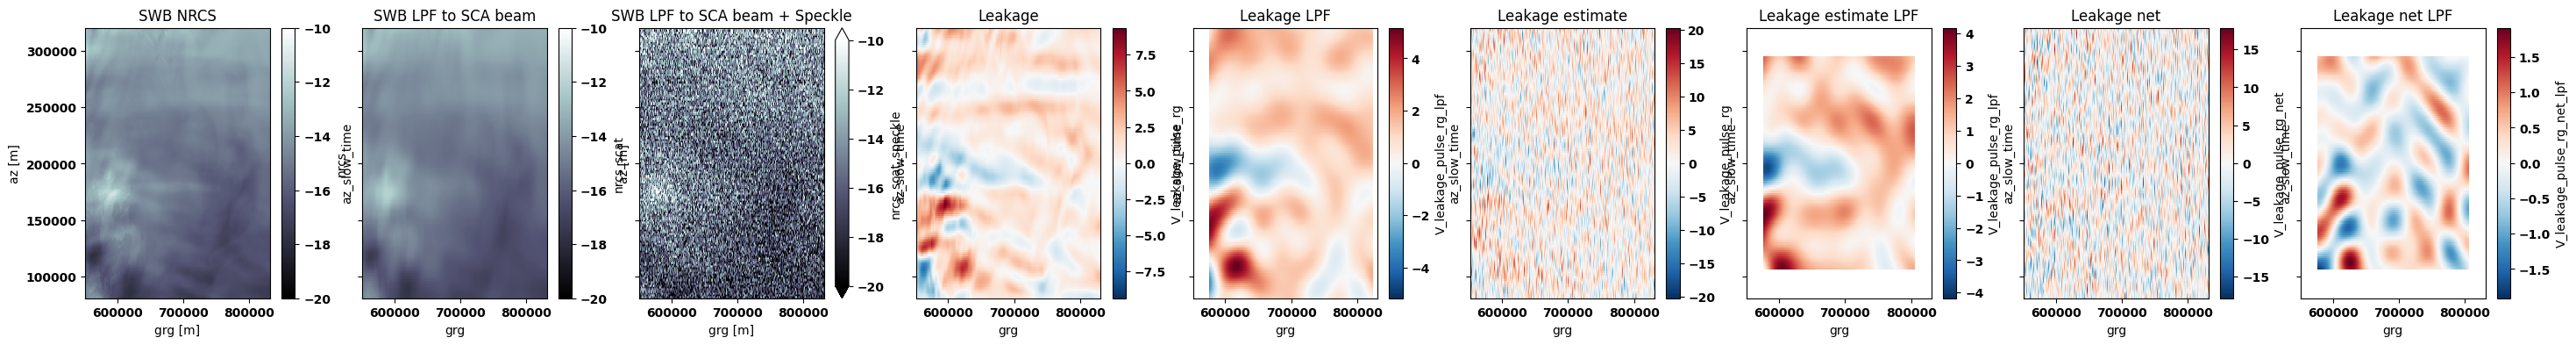

In [25]:
fig, axes = plt.subplots(ncols=9, nrows=1, sharex=True, sharey=True, figsize = (36, 4))

vmin = -20; vmax = -10
dB(data_clean.nrcs).plot(ax = axes[0], cmap = 'bone', vmin=vmin, vmax=vmax)
dB(ds.nrcs_scat).plot(ax = axes[1], cmap = 'bone', vmin=vmin, vmax=vmax)
dB(data_clean.nrcs_scat_speckle).plot(ax = axes[2], cmap = 'bone', vmin=vmin, vmax=vmax)
ds.V_leakage_pulse_rg.plot(ax = axes[3])
ds.V_leakage_pulse_rg_lpf.plot(ax = axes[4])
ds_filt["V_leakage_pulse_rg"].plot(ax = axes[5])
ds_filt["V_leakage_pulse_rg_lpf"].plot(ax = axes[6])
ds_filt["V_leakage_pulse_rg_net"].plot(ax = axes[7])
ds_filt["V_leakage_pulse_rg_net_lpf"].plot(ax = axes[8])

# _ = [ax.set_aspect('equal') for ax in axes]

_ = axes[0].set_title("SWB NRCS")
_ = axes[1].set_title("SWB LPF to SCA beam")
_ = axes[2].set_title("SWB LPF to SCA beam + Speckle")
_ = axes[3].set_title("Leakage")
_ = axes[4].set_title("Leakage LPF")
_ = axes[5].set_title("Leakage estimate")
_ = axes[6].set_title("Leakage estimate LPF")
_ = axes[7].set_title("Leakage net")
_ = axes[8].set_title("Leakage net LPF")

In [26]:
print(f"Incurred leakage (LPF): {func_rmse(ds["V_leakage_pulse_rg_lpf"])} m/s")
print(f"Residual leakage after correction (LPF): {func_rmse(ds_filt['V_leakage_pulse_rg_net_lpf'])} m/s")

Incurred leakage (LPF): 1.379 m/s
Residual leakage after correction (LPF): 0.521 m/s
